# Evaluation of TREX savings

This notebook evaluates the savings of the TREX representation compared to simple
representations. It reads `merged.csv` -- the output of `evaluation/pipeline.py` over the
five dataset categories, concatenated by `merge-results.sh` -- computes derived columns for
savings and entropy reduction, and reports the aggregate finding.

**What is being compared.** Every number below is *information-theoretic* bits: the bits the
analysis of Theorem 1.8 charges (entropies, the combinatorial term for the separator
bitvector, and the exact linear terms). The `o(m)`/`o(n)` redundancy that the rank/select
structures add on top is deliberately **not** included in any total, and neither are the
constant factors of a concrete implementation. These are therefore *idealised* space figures
for three encodings of the same graph, not measured file sizes.

Three rows are priced, matching steps (0), (2) and (3b) of the companion website:

| row | what it is | space |
|---|---|---|
| (0) | array-based adjacency lists | `m*ceil(lg n) + n*ceil(lg m)` |
| (2) | entropy-compressed adjacency string + separator bitvector | `H(G) + lg C(n+m, n)` |
| (3b) | TREX with the greedy MST-based tree | `H(G-T) + lg C(n+m', n) + 3n` (`2n` undirected) |

For undirected graphs, row (0) stores every edge twice (as a textbook adjacency list does),
while rows (2) and (3b) store each edge once, oriented towards its busier endpoint; `H(G)`
is then the in-degree entropy of that orientation. This is why directed and undirected
graphs are never pooled on a bits-per-edge axis below.

All figures are themed from one place: set `THEME` in the first code cell to `"web"` (the
companion-website palette), `"paper"` (neutral, white, colourblind-safe) or `"mono"`
(greyscale for print). Filenames carry the theme, so both versions can live side by side.

Meaning of the columns in `merged.csv`:

* `n`: number of nodes
* `m`: number of edges
* `type`: directed or undirected
* `indegree entropy`: H(G), the entropy of the indegree distribution for directed graphs; -1 for undirected graphs
* `indegree entropy greedy`: H(G_greedy), the entropy of the indegree distribution for greedily oriented undirected graphs; -1 for directed graphs
* `array total bits`: total bits for the array representation
* `bitvector total bits`: total bits for the bitvector representation
* `bitvector greedy total bits`: total bits for the bitvector representation of greedily oriented undirected graphs
* `total bits trex`: total bits for the TREX representation
* `trex entropy`: H(G-T), the entropy of the indegree distribution after removing the extracted tree
* `total bits planar`: total bits for the planar representation
* `planar edges`: number of edges in the planar representation


In [1]:
# Use on local copy to produce PGF exports
enablePgfExports = True
# Hint: search and replace "plt.show()" by "plt.close()" to produce
# figures from paper in batch mode

import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


if enablePgfExports:
  import matplotlib
  from matplotlib.backends.backend_pgf import FigureCanvasPgf
  matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)
  plt.rcParams.update({
      "pgf.texsystem": "pdflatex",
      "pgf.rcfonts": False,              # stop the DejaVu preamble being emitted
      "pgf.preamble": r"\usepackage{amsmath}\usepackage{lmodern}",   # match your document
      "font.family": "serif",
      "font.size": 9,                    # your \normalsize, so sizes agree
  })
# using layout="constrained" re-runs drawing via actual backend, needs to be added to figure

def my_savefig(name):
    fig = plt.gcf()
    canvas = fig.canvas                      # the interactive one
    try:
        if enablePgfExports:
            fig.savefig(f'figures/{name}.pgf')
            fig.savefig(f'figures/{name}.pdf')
            fig.savefig(f'figures/{name}.png', dpi=500)
        else:
            fig.savefig(f'figures/{name}.png')
    finally:
        fig.set_canvas(canvas)               # hand the GUI its canvas back

from evaluation.ledger import PALETTE, series_colours, use_theme

# "web"   -- the colours of the companion website
# "paper" -- neutral, white background, colourblind-safe (Okabe-Ito), serif
# "mono"  -- greyscale ramp, for black-and-white printing
THEME = "paper"

use_theme(THEME)                       # styles every figure below, not just the ledger
C_BASE, C_ENT, C_TREX, C_ALT = series_colours()

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
df = pd.read_csv("merged.csv")

# H(G) and row (2) come from different columns depending on the graph type
directed = df["type"].eq("directed")
df["H(G)"] = np.where(directed, df["indegree entropy"], df["indegree entropy greedy"])
df["(0) adjacency lists"] = df["array total bits"]
df["(2) entropy-compressed"] = np.where(
    directed, df["bitvector total bits"], df["bitvector greedy total bits"])
df["(3b) TREX"] = df["total bits trex"]
df["H(G-T)"] = df["trex entropy"]

df["n lg n"] = df["n"] * np.log2(df["n"])
df["lg(n!)"] = [math.lgamma(n + 1) / math.log(2) for n in df["n"]]
df["density"] = df["m"] / df["n"]
df["H per edge"] = df["H(G)"] / df["m"]          # H^in_deg(G), bits per edge

# the two savings, which answer different questions -- see below
df["saving (2)->(3b)"] = df["(2) entropy-compressed"] - df["(3b) TREX"]
df["saving (0)->(3b)"] = df["(0) adjacency lists"] - df["(3b) TREX"]
df["entropy reduction"] = df["H(G)"] - df["H(G-T)"]

df["% saved vs (0)"] = 100 * df["saving (0)->(3b)"] / df["(0) adjacency lists"]
df["% saved vs (2)"] = 100 * df["saving (2)->(3b)"] / df["(2) entropy-compressed"]
df["saving / n lg n"] = df["saving (2)->(3b)"] / df["n lg n"]
df["entropy reduction / n lg n"] = df["entropy reduction"] / df["n lg n"]
df["saving / lg(n!)"] = df["saving (2)->(3b)"] / df["lg(n!)"]

df["bpe (0)"] = df["(0) adjacency lists"] / df["m"]
df["bpe (2)"] = df["(2) entropy-compressed"] / df["m"]
df["bpe (3b)"] = df["(3b) TREX"] / df["m"]

# how much of row (2) could in principle be vertex labels
df["label share of (2)"] = 100 * df["n lg n"] / df["(2) entropy-compressed"]

df["graph"] = df["Dataset"].str.replace(r"\.txt$", "", regex=True).str.slice(0, 26)

# Read in type of graphs from file; see thesis.pdf for origin of graphs.
MANIFEST = "Datasets/all-graphs.txt"
meta = {}
with open(MANIFEST) as f:
    for ln in f:
        ln = ln.split("#", 1)[0].split()
        if len(ln) >= 4:
            meta[os.path.basename(ln[0])] = (ln[2], ln[3])
df["origin"] = df["Dataset"].map(lambda d: meta[d][0])
df["role"] = df["Dataset"].map(lambda d: meta[d][1])
df["class"] = np.where(df["origin"].eq("real"), "real-world",
                       "synthetic / " + df["role"])

CLASS_ORDER = ["real-world", "synthetic / benchmark", "synthetic / illustration"]
df["class"] = pd.Categorical(df["class"], CLASS_ORDER, ordered=True)

df = df.sort_values(["type", "density"]).reset_index(drop=True)
directed = df["type"].eq("directed")
real = df["origin"].eq("real")            # the 15 real-world networks
headline = real                           # what the aggregate claim is about
print(f"{len(df)} graphs: {directed.sum()} directed, {(~directed).sum()} undirected")
print(df["class"].value_counts().reindex(CLASS_ORDER).to_string())
print(f"n from {df['n'].min():,} to {df['n'].max():,}, "
      f"m from {df['m'].min():,} to {df['m'].max():,}")

21 graphs: 11 directed, 10 undirected
class
real-world                  15
synthetic / benchmark        3
synthetic / illustration     3
n from 8 to 1,088,092, m from 14 to 6,797,557


## The headline numbers

Two quantities are reported throughout, and they are **not** the same thing:

* the **encoding saving** `(2) - (3b)`: two complete encodings of the same graph compared
  against each other. This is the number a user of the data structure feels. The part of it
  that comes from dropping the vertex names is at most `lg(n!) ~ n lg n` bits.
* the **entropy reduction** `H(G) - H(G-T)`: what MINETREX actually optimises, and what
  Theorems 1.6 and 1.7 bound. It is not capped by `lg(n!)`.

**The 21 graphs are not one population.** Fifteen are real networks; two come from random
models (Erdos-Renyi, Barabasi-Albert); three are deterministic constructions built to make a
point (`G_bipartite` is complete K(1000,1000); `graph_A_skewed` and `graph_B_uniform` come
from `Tests/sameDensity.py`, which builds two graphs of identical density and very different
compression ratio on purpose); and `fig2-example` is the n = 8 illustration from the paper.


In [3]:
def q(s):
    return pd.Series({"median": s.median(), "q25": s.quantile(.25), "q75": s.quantile(.75),
                      "min": s.min(), "max": s.max()})

cols = ["% saved vs (0)", "% saved vs (2)", "saving / n lg n",
        "entropy reduction / n lg n", "saving / lg(n!)", "bpe (0)", "bpe (2)", "bpe (3b)"]
blocks = {
    f"REAL-WORLD ({real.sum()})":                      df[real][cols].apply(q),
    f"  directed ({(real & directed).sum()})":          df[real & directed][cols].apply(q),
    f"  undirected ({(real & ~directed).sum()})":       df[real & ~directed][cols].apply(q),
}
for c in CLASS_ORDER:
    sel = df["class"].eq(c)
    if sel.any():
        blocks[f"{c} ({sel.sum()})"] = df[sel][cols].apply(q)
blocks[f"all graphs ({len(df)}) -- mixes real and synthetic, do not quote"] = df[cols].apply(q)
summary = pd.concat(blocks, axis=0).round(3)
summary

% saved vs (0)  % saved vs (2)  saving / n lg n  entropy reduction / n lg n  saving / lg(n!)  bpe (0)  bpe (2)  bpe (3b)
REAL-WORLD (15)                                    median          54.120           8.918            0.950                       1.118            1.041   22.457   12.743    10.235
                                                   q25             28.114           5.282            0.907                       1.030            1.013   18.133   10.707     8.337
                                                   q75             63.509          27.835            0.962                       1.141            1.077   33.780   14.969    13.178
                                                   min             13.944           3.172            0.620                       0.715            0.695   10.520    8.072     4.520
                                                   max             87.614          64.295            1.029                       1.257            1.123   57.525   21.002    14.678
  directed (8)                                     median          28.114           8.637            0.946                       1.139            1.040   18.133   14.489    11.639
                                                   q25             26.662           7.257            0.902                       1.092            1.016   13.272   10.648     9.673
                                                   q75             32.184          12.834            0.960                       1.146            1.057   19.973   15.101    13.662
                                                   min             13.944           3.971            0.710                       0.937            0.800   10.520    8.072     7.220
                                                   max             54.120          35.979            0.979                       1.257            1.123   22.457   18.277    14.678
  undirected (7)                                   median          63.882           9.870            0.950                       1.066            1.041   35.759   12.659    10.186
                                                   q25             62.512           4.631            0.910                       0.971            1.013   29.264   10.707     6.290
                                                   q75             86.411          54.247            0.964                       1.122            1.092   36.542   13.338    10.861
                                                   min             58.768           3.172            0.620                       0.715            0.695   24.824    9.042     4.520
                                                   max             87.614          64.295            1.029                       1.143            1.123   57.525   21.002    13.490
real-world (15)                                    median          54.120           8.918            0.950                       1.118            1.041   22.457   12.743    10.235
                                                   q25             28.114           5.282            0.907                       1.030            1.013   18.133   10.707     8.337
                                                   q75             63.509          27.835            0.962                       1.141            1.077   33.780   14.969    13.178
                                                   min             13.944           3.172            0.620                       0.715            0.695   10.520    8.072     4.520
                                                   max             87.614          64.295            1.029                       1.257            1.123   57.525   21.002    14.678
synthetic / benchmark (3)                          median          54.772           1.842            0.905                       1.043            1.007   30.420   14.056    13.064
                                                   q25             54.709           1.015          

### Figure 1 -- every graph, priced three ways

Bits per edge, so that graphs of very different size sit on one axis. Directed and
undirected are drawn in separate panels because row (0) double-stores undirected edges;
comparing the two panels' bar lengths would not be meaningful. Within a panel the graphs are
ordered by density `m/n`, which turns out to be the variable that matters.


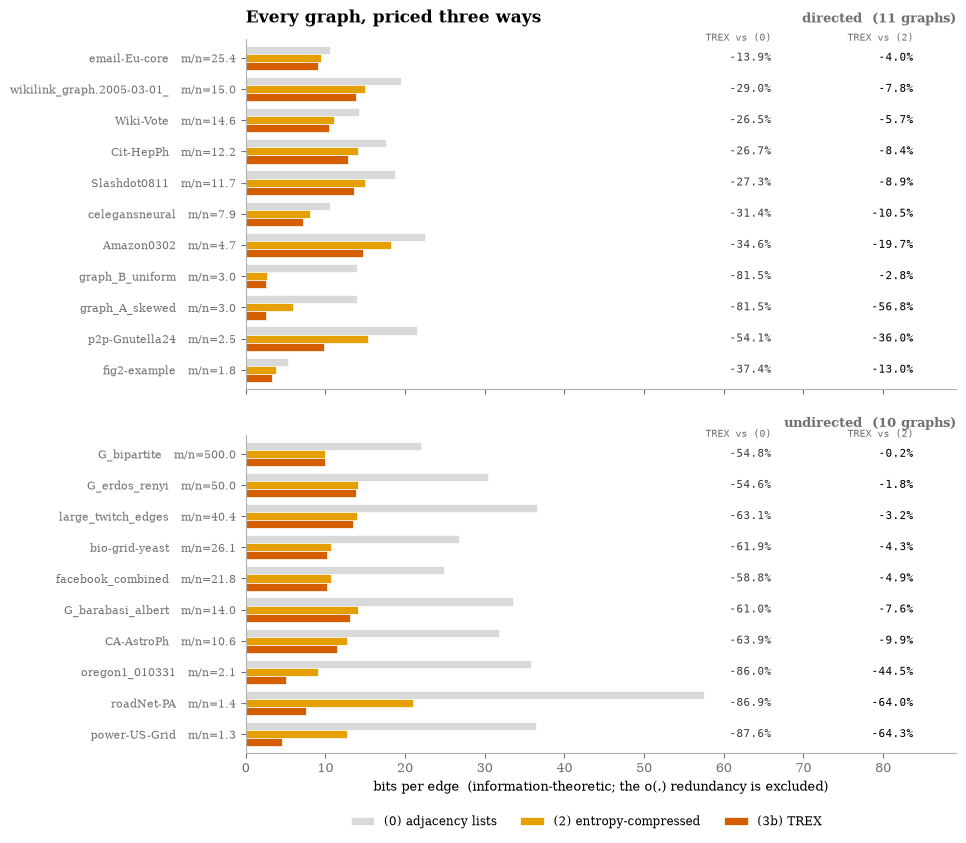

In [4]:
xmax = df["bpe (0)"].max() * 1.55
groups = [("directed", df[directed]), ("undirected", df[~directed])]
fig, axes = plt.subplots(
    2, 1, figsize=(9.6, 8.6), sharex=True,
    gridspec_kw={"height_ratios": [len(g) for _, g in groups]})
for ax, (kind, part) in zip(axes, groups):
    o = part.sort_values("density").reset_index(drop=True)
    h = 0.26
    for i, r in o.iterrows():
        for k, (col, c, lab) in enumerate([("bpe (0)", C_BASE, "(0) adjacency lists"),
                                           ("bpe (2)", C_ENT, "(2) entropy-compressed"),
                                           ("bpe (3b)", C_TREX, "(3b) TREX")]):
            ax.barh(i + (1 - k) * h, r[col], height=h, color=c,
                    edgecolor=PALETTE["panel"], linewidth=.5,
                    label=lab if (i == 0 and kind == "directed") else None)
        ax.text(xmax * .74, i, f"{-r['% saved vs (0)']:6.1f}%", va="center", ha="right",
                fontsize=8, family="monospace", color=PALETTE["ink_soft"])
        ax.text(xmax * .94, i, f"{-r['% saved vs (2)']:6.1f}%", va="center", ha="right",
                fontsize=8, family="monospace", color=PALETTE["ink"])
    ax.set_yticks(range(len(o)))
    ax.set_yticklabels([f"{g}   m/n={d:.1f}" for g, d in zip(o["graph"], o["density"])],
                       fontsize=8)
    ax.set_ylim(-0.6, len(o) - 0.4)
    ax.set_xlim(0, xmax)
    ax.set_title(f"{kind}  ({len(o)} graphs)", loc="right", fontsize=9,
                 color=PALETTE["ink_faint"])
    ax.text(xmax * .74, len(o) - .45, "TREX vs (0)", ha="right", fontsize=7.5,
            family="monospace", color=PALETTE["ink_faint"])
    ax.text(xmax * .94, len(o) - .45, "TREX vs (2)", ha="right", fontsize=7.5,
            family="monospace", color=PALETTE["ink_faint"])
axes[0].set_title("Every graph, priced three ways", loc="left", fontsize=12, pad=12)
axes[-1].set_xlabel("bits per edge  (information-theoretic; the o(.) redundancy is excluded)")
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, frameon=False, loc="lower center", ncol=3, fontsize=8.5,
           bbox_to_anchor=(0.6, 0.0))
fig.subplots_adjust(left=.245, right=.985, top=.93, bottom=.10, hspace=.14)
fig.savefig(f"figures/fig1-per-graph-{THEME}.pdf")
plt.show()

### Figure 2 -- the saving is the vertex labels

Both savings, in units of `n lg n`. The dashed line marks `n lg n` exactly.

Only the 15 real-world networks carry the claim; the three synthetic benchmarks sit below
the rule for context, and `graph_A`/`graph_B`/`fig2-example` are left out entirely, since they
are constructions chosen to illustrate a mechanism rather than evidence about graphs.
On the real-world networks the encoding saving clusters just below 1: tree extraction
recovers close to the whole label information and no more, which is what
`lg(n!) = n lg n - n lg e + O(lg n)` allows. A few undirected graphs sit slightly above 1;
that surplus is *not* label information, but slack in row (2), which pays `lg m` for every
tree edge that row (3b) keeps in about two bits.

The entropy reduction is systematically larger and regularly exceeds `n lg n` -- it is a
different quantity and nothing caps it at the label information.


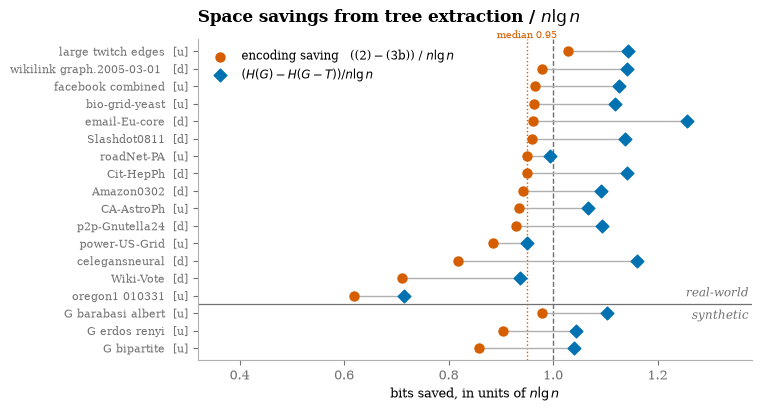

real-world (15)      saving/n lg n  median 0.950  IQR [0.907, 0.962]   entropy red.  median 1.118
  directed (8)       saving/n lg n  median 0.946  IQR [0.902, 0.960]   entropy red.  median 1.139
  undirected (7)     saving/n lg n  median 0.950  IQR [0.910, 0.964]   entropy red.  median 1.066
synthetic bench (3)  saving/n lg n  median 0.905  IQR [0.881, 0.942]   entropy red.  median 1.043


In [5]:
main = df[real].sort_values("saving / n lg n")
extra = df[df["class"].eq("synthetic / benchmark")].sort_values("saving / n lg n")
o2 = pd.concat([extra, main]).reset_index(drop=True)
split = len(extra) - 0.5                      # rule between the two groups

# layout="constrained" re-runs drawing via actual backend
fig, ax = plt.subplots(figsize=(7.5, 4), layout="constrained")
ax.axvline(1.0, color=PALETTE["ink_faint"], lw=1, ls="--", zorder=0)
for i, r in o2.iterrows():
    ax.plot([r["saving / n lg n"], r["entropy reduction / n lg n"]], [i, i],
            color=PALETTE["border"], lw=1, zorder=1)
ax.scatter(o2["saving / n lg n"], range(len(o2)), s=42, color=C_TREX, zorder=2,
           label="encoding saving   ((2)${}-{}$(3b)) / $n \\lg n$")
ax.scatter(o2["entropy reduction / n lg n"], range(len(o2)), s=42, color=C_ALT,
           marker="D", zorder=2, label="$(H(G) - H(G-T)) / n \\lg n$")
ax.axhline(split, color=PALETTE["ink_faint"], lw=0.9)
for y, txt, va in [(split - 0.3, "synthetic", "top"), (split + 0.3, "real-world", "bottom")]:
    ax.text(0.995, y, txt, transform=ax.get_yaxis_transform(), fontsize=8.5,
            ha="right", va=va, color=PALETTE["ink_faint"], style="italic")

med = df[real]["saving / n lg n"].median()
ax.axvline(med, color=C_TREX, lw=1, ls=":", zorder=0)
ax.set_yticks(range(len(o2)))
# Replace underscore in graph names by space and remove trailing space
ax.set_yticklabels([f"{g.replace('_', ' ')}  [{t[0]}]" for g, t in zip(o2["graph"], o2["type"])], fontsize=8)
ax.set_ylim(-0.7, len(o2) - 0.3)
ax.set_xlabel("bits saved, in units of $n \\lg n$")
ax.set_xlim(0.32,1.38)
ax.set_title("Space savings from tree extraction / $n \\lg n$",
             loc="left", fontsize=12, pad=12)
#ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=8.5)
ax.text(med, len(o2) - .25, f"median {med:.2f}", ha="center", fontsize=7.5,
        color=C_TREX)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
#fig.tight_layout() # DON'T do this with constrained layout
#fig.savefig(f"figures/fig2-n-lg-n-{THEME}.pdf")
my_savefig(f"fig2-n-lg-n-{THEME}")
plt.show()

for label, sel in [("real-world (15)", real),
                   ("  directed (8)", real & directed),
                   ("  undirected (7)", real & ~directed),
                   ("synthetic bench (3)", df["class"].eq("synthetic / benchmark"))]:
    a, b = df[sel]["saving / n lg n"], df[sel]["entropy reduction / n lg n"]
    print(f"{label:20} saving/n lg n  median {a.median():.3f}  "
          f"IQR [{a.quantile(.25):.3f}, {a.quantile(.75):.3f}]   "
          f"entropy red.  median {b.median():.3f}")

### Figure 3 -- when tree extraction pays, and when it does not

If the absolute saving is pinned near `n lg n`, then the *relative* saving must be roughly
`n lg n` divided by the size of row (2) -- i.e. it is a statement about density, not about
any particular network. Figure 3 tests exactly that: the x-axis is the predicted ceiling
`n lg n / (2)`, the y-axis is what was actually saved, and the dashed line is equality.

Note that this is a re-plot, not new evidence: the vertical distance to the diagonal is by
construction the encoding-saving ratio of Figure 2. What Figure 3 adds is the *scale* -- it
shows the level of relative saving a user would actually see, which ranges over three orders
of magnitude across these graphs while the ratio to `n lg n` barely moves.

Most graphs sit just under the diagonal. The interesting points are the ones that do not,
and they are the honest part of the story.

**`graph_B_uniform`** is the clear failure: predicted 125%, actual 2.8%. The name is about
the *out*-degrees -- every one of the 1000 vertices emits 3 arcs -- but the in-degrees, which
are what `H(G)` and tree extraction see, are as concentrated as they can be: three hub
vertices absorb all 2997 arcs (in-degree 999 each) and the remaining 997 vertices have
in-degree 0. So `H(G) = m lg 3`, only 2.67 bits per edge, and the whole graph already fits in
4751 bits. The greedy tree does remove 2731 bits of entropy, but the `3n = 3000` bits for
LOUDS and `D` cost more than that, and the net gain is almost nil.

This is exactly the regime the theory flags. Theorem 1.7's `alpha = n / #{v : indeg(v) > 0}`
is 333 for `graph_B_uniform` against 1 for `graph_A_skewed`, so the leading term
`(n / 2 alpha) * H^in_deg` of the guarantee is worth 2.4 bits on B and 2453 bits on A -- a
factor of a thousand, in the direction the measurements go. (At `n = 1000` the `-2n/ln 2`
correction makes the bound itself vacuous for *both* graphs; the theorems are asymptotic, and
these two synthetic graphs are far too small for them to bite. What transfers here is the
diagnostic `alpha`, not the numerical guarantee.)

**`graph_A_skewed`** is the deliberate contrast: same `n`, same `m`, but 997 vertices of
in-degree 1. Each of those is an arc costing the full `lg m` bits, and a tree can take one
per vertex -- the best possible case. Tree extraction removes 57% of row (2).

Both come from `Tests/sameDensity.py`, whose comment states the intent plainly: two graphs
with the same density and very different TREX compression ratio. The names mislead --
"uniform" in `graph_B_uniform` refers to the *out*-degrees (every vertex emits three arcs);
the in-degrees, which are what `H(G)` and tree extraction see, are `{0: 997, 999: 3}`.

**`oregon1_010331`** and **`fig2-example`** fall short more mildly. `fig2-example` has `n = 8`,
where the linear terms simply dominate anything else in the ledger. `oregon1_010331` is the
one *real* network that lands clearly below the diagonal, and it is the interesting case: at
0.62 `n lg n` it is the honest reminder that the clustering near 1 is a tendency, not a law.


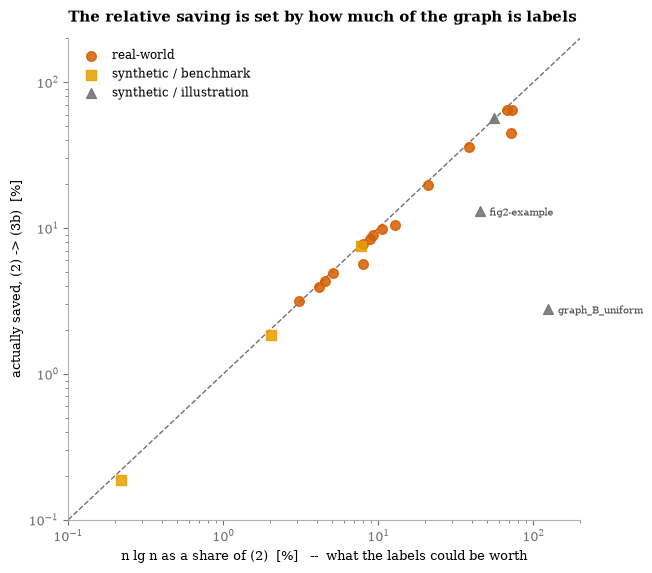

the three graphs furthest below the diagonal:
          graph       type  label share of (2)  % saved vs (2)  saving / n lg n
graph_B_uniform   directed             124.761           2.772            0.022
   fig2-example   directed              45.091          13.005            0.288
 oregon1_010331 undirected              71.772          44.494            0.620


In [6]:
fig, ax = plt.subplots(figsize=(6.6, 5.8))
lo, hi = 0.1, 200
ax.plot([lo, hi], [lo, hi], color=PALETTE["ink_faint"], lw=1, ls="--", zorder=0)
STYLE = {"real-world": ("o", C_TREX, 48), "synthetic / benchmark": ("s", C_ENT, 46),
         "synthetic / illustration": ("^", PALETTE["ink_faint"], 50)}
for cls in CLASS_ORDER:
    sel = df["class"].eq(cls)
    if not sel.any():
        continue
    mk, col, sz = STYLE[cls]
    ax.scatter(df[sel]["label share of (2)"], df[sel]["% saved vs (2)"], s=sz,
               marker=mk, color=col, alpha=.85, label=cls, zorder=2)
for _, r in df.iterrows():
    if r["% saved vs (2)"] < 0.42 * r["label share of (2)"]:
        ax.annotate(r["graph"], (r["label share of (2)"], r["% saved vs (2)"]),
                    textcoords="offset points", xytext=(7, -3), fontsize=7.5,
                    color=PALETTE["ink_soft"])
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("n lg n as a share of (2)  [%]   --  what the labels could be worth")
ax.set_ylabel("actually saved, (2) -> (3b)  [%]")
ax.set_title("The relative saving is set by how much of the graph is labels",
             loc="left", fontsize=11, pad=12)
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
fig.tight_layout()
fig.savefig(f"figures/fig3-when-it-pays-{THEME}.pdf")
plt.show()

# note: vertical distance to the diagonal is, by construction, exactly the encoding
# saving of Figure 2 -- y/x = ((2)-(3b)) / (n lg n).  Figure 3 adds the scale, not new data.
worst = df.nsmallest(3, "saving / n lg n")[["graph", "type", "label share of (2)",
                                            "% saved vs (2)", "saving / n lg n"]]
print("the three graphs furthest below the diagonal:")
print(worst.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

In [7]:
# The Theorem 1.7 diagnostic for the two synthetic contrasts, if the datasets are unpacked.
import os

from evaluation.ledger import compression_bounds, compression_ledger, read_graph

pairs = [("Datasets/GA_and_GB/graph_A_skewed.txt", False),
         ("Datasets/GA_and_GB/graph_B_uniform.txt", False)]
rows = []
for path, undir in pairs:
    if not os.path.exists(path):
        continue
    G = read_graph(path, undir)
    led = compression_ledger(G, os.path.basename(path), with_twins=False)
    b = compression_bounds(led, G, exact_density=False)
    rows.append({
        "graph": os.path.basename(path),
        "H^in_deg [bits/edge]": b["H^in_deg(G) (bits/edge)"],
        "vertices with indeg > 0": b["vertices with non-zero in-degree"],
        "alpha (Thm 1.7)": b["alpha (Thm 1.7)"],
        "(n/2a)*H^in_deg [bits]": led.n / (2 * b["alpha (Thm 1.7)"]) * b["H^in_deg(G) (bits/edge)"],
        "2n/ln2 [bits]": 2 * led.n / math.log(2),
        "achieved H(G)-H(G-T)": b["achieved saving, best tree"],
    })
pd.DataFrame(rows).round(2) if rows else print("unpack Datasets/*.zip to run this cell")

,graph,H^in_deg [bits/edge],vertices with indeg > 0,alpha (Thm 1.7),(n/2a)*H^in_deg [bits],2n/ln2 [bits],achieved H(G)-H(G-T)
0,graph_A_skewed.txt,4.91,1000,1.00,2452.87,2885.39,12693.10
1,graph_B_uniform.txt,1.58,3,333.33,2.38,2885.39,2731.32


### The per-graph table

The full numbers behind the figures, and a LaTeX version for the paper.


In [8]:
show = ["graph", "class", "type", "n", "m", "density", "H per edge",
        "bpe (0)", "bpe (2)", "bpe (3b)", "% saved vs (0)", "% saved vs (2)",
        "saving / n lg n", "entropy reduction / n lg n"]
table = df[show].copy()
table.round(3)

,graph,class,type,n,m,density,H per edge,bpe (0),bpe (2),bpe (3b),% saved vs (0),% saved vs (2),saving / n lg n,entropy reduction / n lg n
0,fig2-example,synthetic / illustration,directed,8,14,1.750,2.496,5.286,3.802,3.307,37.428,13.005,0.288,1.054
1,p2p-Gnutella24,real-world,directed,26518,65369,2.465,14.183,21.491,15.401,9.860,54.120,35.979,0.930,1.093
2,graph_A_skewed,synthetic / illustration,directed,1000,2997,2.997,4.906,14.004,5.986,2.588,81.517,56.761,1.022,1.274
3,graph_B_uniform,synthetic / illustration,directed,1000,2997,2.997,1.585,14.004,2.665,2.591,81.495,2.772,0.022,0.274
4,Amazon0302,real-world,directed,262111,1234877,4.711,17.466,22.457,18.277,14.678,34.641,19.692,0.942,1.092
5,celegansneural,real-world,directed,297,2345,7.896,7.503,10.520,8.072,7.220,31.365,10.548,0.818,1.161
6,Slashdot0811,real-world,directed,77360,905468,11.705,14.506,18.709,14.938,13.606,27.277,8.918,0.960,1.137
7,Cit-HepPh,real-world,directed,34546,421578,12.203,13.622,17.557,14.040,12.867,26.712,8.356,0.950,1.141
8,Wiki-Vote,real-world,directed,7115,103689,14.573,10.667,14.167,11.034,10.411,26.512,5.650,0.710,0.937
9,wikilink_graph.2005-03-01_,real-world,directed,244112,3659390,14.991,14.640,19.468,15.000,13.831,28.951,7.792,0.979,1.141


In [9]:
tex = table.copy()
tex["graph"] = tex["graph"].str.replace("_", r" ", regex=False)
tex.columns = ["graph", "class", "type", "$n$", "$m$", "$m/n$",
               r"$\mathcal{H}^{in}_{deg}$", "(0)", "(2)", "(3b)",
               r"vs (0) [\%]", r"vs (2) [\%]",
               r"$\frac{(2)-(3b)}{n\lg n}$", r"$\frac{H(G)-H(G-T)}{n\lg n}$"]
tex["type"] = tex["type"].str[0]
#tex["class"] = tex["class"].astype(str).map(
#    {"real network": "real", "random model": "rand", "constructed": "constr", "toy": "toy"})
latex = tex.to_latex(index=False, escape=False, float_format="%.2f",
                     column_format="lllrrrrrrrrrrr")
with open("figures/table1.tex", "w") as f:
    f.write(latex)
print(latex[:1200])

\begin{tabular}{lllrrrrrrrrrrr}
\toprule
graph & class & type & $n$ & $m$ & $m/n$ & $\mathcal{H}^{in}_{deg}$ & (0) & (2) & (3b) & vs (0) [\%] & vs (2) [\%] & $\frac{(2)-(3b)}{n\lg n}$ & $\frac{H(G)-H(G-T)}{n\lg n}$ \\
\midrule
fig2-example & synthetic / illustration & d & 8 & 14 & 1.75 & 2.50 & 5.29 & 3.80 & 3.31 & 37.43 & 13.00 & 0.29 & 1.05 \\
p2p-Gnutella24 & real-world & d & 26518 & 65369 & 2.47 & 14.18 & 21.49 & 15.40 & 9.86 & 54.12 & 35.98 & 0.93 & 1.09 \\
graph A skewed & synthetic / illustration & d & 1000 & 2997 & 3.00 & 4.91 & 14.00 & 5.99 & 2.59 & 81.52 & 56.76 & 1.02 & 1.27 \\
graph B uniform & synthetic / illustration & d & 1000 & 2997 & 3.00 & 1.58 & 14.00 & 2.67 & 2.59 & 81.50 & 2.77 & 0.02 & 0.27 \\
Amazon0302 & real-world & d & 262111 & 1234877 & 4.71 & 17.47 & 22.46 & 18.28 & 14.68 & 34.64 & 19.69 & 0.94 & 1.09 \\
celegansneural & real-world & d & 297 & 2345 & 7.90 & 7.50 & 10.52 & 8.07 & 7.22 & 31.37 & 10.55 & 0.82 & 1.16 \\
Slashdot0811 & real-world & d & 77360 & 90

## Caveats

Stated plainly, because they bound what the numbers above support:

1. **Idealised space, not measured space.** The `o(m)`/`o(n)` redundancy of the rank/select
   structures is excluded from every total, as are implementation constants. On graphs of
   this size that redundancy is not negligible in practice; these figures are the
   information-theoretic content the analysis charges, and an implementation will sit above
   them. Query time is not measured here at all.
2. **One tree per graph.** Rows (3b) use the greedy MST-based tree only. The range of the
   approximation -- how much worse the *worst* MST-based tree is -- is not in `merged.csv`;
   `evaluation/ledger.py` computes it per graph as row (3w), and it is small on real
   networks and large on the synthetic ones.
3. **Twin removal is not included.** Every TREX number in `merged.csv` is Theorem 1.8, not
   Theorem 5.1. `evaluation/run_ledger_all.py` adds it as row (4), and the effect is uneven:
   `oregon1_010331` gains 17% on top of (3b), `graph_B_uniform` 99% (997 of its 1000 vertices
   are twins), while `power-US-Grid` *loses* 1.3% -- with few twins you still pay
   `lg C(N, n0)` for the class sizes.
4. **15 real-world networks is a convenience sample.** Eight appear in Table 1 of the
   thesis and seven were added there as a validation sample for the compression-potential
   heuristic of section 4.3.4. That split serves that heuristic and nothing else, so all 15
   are pooled here; `role` is kept in the per-graph table only as provenance. The remaining
   six graphs are three synthetic benchmarks and three illustrations, none of which is
   evidence about how graphs in the wild behave. The density trend in Figure 3 is a
   mechanism, not a fitted law, and the sample is far too small to estimate an exponent
   from.
5. **The three `Synthetic/` graphs were re-evaluated for this version.** `generator.py`
   creates them with `nx.erdos_renyi_graph`, `nx.complete_bipartite_graph` and
   `nx.barabasi_albert_graph` -- all undirected -- but `run-all.sh` keys directedness on the
   string "Undirected" in the path, so they had been priced as digraphs under an arbitrary
   orientation. They now go through the pipeline with `undirected=True`. The effect is
   largest on Barabasi-Albert (5.65% -> 7.56% saved vs (2)); the original rows are kept in
   `merged-before-synthetic-fix.csv`.
6. **Not compared against practical graph compressors.** The baseline is a textbook
   adjacency list and its entropy-compressed form, not WebGraph or any domain heuristic. The
   claim is about what tree extraction adds to an ultrasuccinct representation, not about
   being the smallest encoding available.
7. `Amazon0302` is the one graph where `evaluation/ledger.py` and `pipeline.py` disagree, by
   0.011% on row (3b), due to tie-breaking among equal MST weights.


## Appendix -- the full ledger for a single graph

`evaluation/ledger.py` prices *all* the steps of the companion website, including the ones
`merged.csv` does not carry: row (1) (uncompressed string plus separator bitvector), row
(1u) (undirected, each edge stored once), row (3w) (the worst MST-based tree) and row (4)
(twin removal). Run it on any edgelist to get the table and the absolute-scale bar chart:

```
python -m evaluation.ledger Datasets/fig2-example.txt
python -m evaluation.ledger Datasets/Undirected/power-US-Grid.txt --undirected
python -m evaluation.ledger --directory Datasets/Directed --outdir figures
```

The cell below runs it on the example of Figure 2 of the paper, if the dataset is unpacked.


,step,name,bits,redundancy,saved vs previous (%),saved vs (0) (%)
0,0,Adjacency lists,74.00,,NaN,0.00
1,1,Adjacency string + bitvector,60.29,o(m),18.53,18.53
2,2,$H_0$-compr.\ wavelet tree,53.23,o(m),11.71,28.07
3,3b,TREX -- best MST,46.30,o(m) + o(n),13.00,37.43
4,3w,TREX -- worst MST,54.30,o(m) + o(n),-17.28,26.62
5,4,Twin removal + TREX,NaN,,NaN,NaN


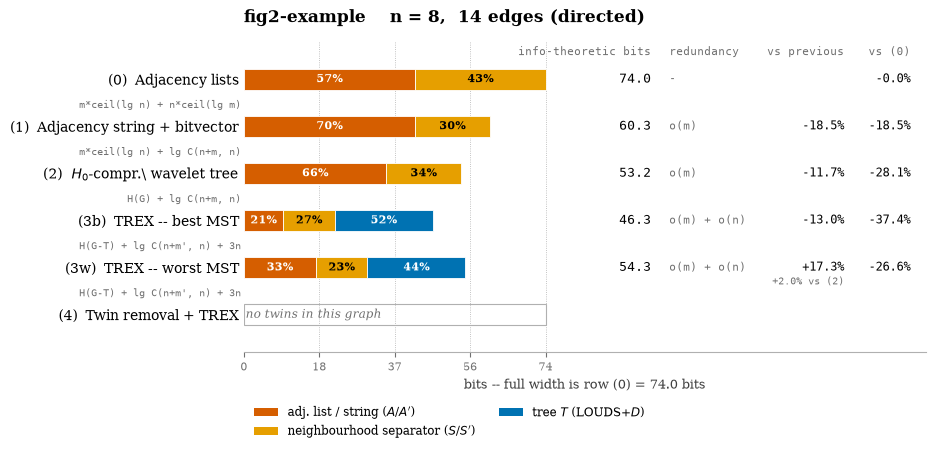

In [10]:
import os

from evaluation.ledger import compression_ledger, plot_ledger, read_graph

path = "Datasets/fig2-example.txt"
if os.path.exists(path):
    led = compression_ledger(read_graph(path, undirected=False), name="fig2-example")
    display(led.frame()[["step", "name", "bits", "redundancy",
                         "saved vs previous (%)", "saved vs (0) (%)"]].round(2))
    fig, _ = plot_ledger(led, absolute=True)   # follows THEME set at the top
    fig.savefig(f"figures/fig4-ledger-fig2-example-{THEME}.pdf")
    plt.show()
else:
    print(f"{path} not found -- unpack Datasets/*.zip first")

In [11]:
# If you have run `python -m evaluation.ledger --directory ... --outdir figures` over the
# datasets, the merged ledger lands in figures/ledger-all.csv and carries the rows that
# merged.csv does not -- in particular the best/worst tree gap, i.e. how much the choice of
# tree is worth on each graph.
if os.path.exists("figures/ledger-all.csv"):
    la = pd.read_csv("figures/ledger-all.csv")
    wide = la.pivot_table(index="graph", columns="step", values="bits")
    gap = pd.DataFrame({
        "best (3b)": wide["3b"],
        "worst (3w)": wide["3w"],
        "tree choice worth [% of (2)]": 100 * (wide["3w"] - wide["3b"]) / wide["2"],
        "twin removal worth [% of (3b)]":
            100 * (wide["3b"] - wide["4"]) / wide["3b"] if "4" in wide else np.nan,
    })
    display(gap.round(3))
else:
    print("figures/ledger-all.csv not found -- see the command above to generate it")

,best (3b),worst (3w),tree choice worth [% of (2)],twin removal worth [% of (3b)]
graph,,,,
Amazon0302,1.812745e+07,1.889775e+07,3.413,0.048
CA-AstroPh,2.275422e+06,2.338850e+06,2.512,0.077
Cit-HepPh,5.424500e+06,5.586527e+06,2.737,0.067
G_barabasi_albert,7.313518e+06,7.555354e+06,3.057,NaN
G_bipartite,9.969229e+06,9.969229e+06,0.000,100.000
G_erdos_renyi,1.378343e+07,1.381195e+07,0.203,NaN
Slashdot0811,1.231943e+07,1.266696e+07,2.569,13.531
Wiki-Vote,1.079472e+06,1.091587e+06,1.059,0.410
bio-grid-yeast,1.598684e+06,1.635103e+06,2.179,0.116
